#  1.  Data Import and Database Integration

In [3]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='123456',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = r'C:\Users\sugam\Desktop\Data Science\Python\Projects\Ecommerce Project  [ SQL + PYTHON]'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "123456",
                             database = "ecommerce")
cur = db.cursor()

# 2. Unique Customer Cities


In [21]:
query = """ select distinct customer_city from customers """

cur.execute(query)

data = cur.fetchall()
df=pd.DataFrame(data)
df.head()
df

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


# 3. Product Category vs Total Sales

In [22]:

query = """
SELECT  upper(products.product_category), round(SUM(payments.payment_value),2) AS sales
FROM products
JOIN order_items ON products.product_id = order_items.product_id
JOIN payments ON payments.order_id = order_items.order_id
GROUP BY products.product_category
"""


cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["category","sales"])
df


,category,sales
0,PERFUMERY,3.243127e+07
1,FURNITURE DECORATION,9.153129e+07
2,TELEPHONY,3.116045e+07
3,BED TABLE BATH,1.096034e+08
4,AUTOMOTIVE,5.454684e+07
...,...,...
69,CDS MUSIC DVDS,7.676352e+04
70,LA CUISINE,1.864659e+05
71,FASHION CHILDREN'S CLOTHING,5.028288e+04
72,PC GAMER,1.391635e+05


# 4. Orders Paid in Installments


In [8]:
query = """ select (sum(case when payment_installments >= 1 then 1
else 0 end)) /count(*)*100  from payments
"""


cur.execute(query)
data = cur.fetchall()
"the percentage of orders that were paid in installments is", data[0][0]


('the percentage of orders that were paid in installments is',
 Decimal('99.9981'))

# 5. Customer Count by State

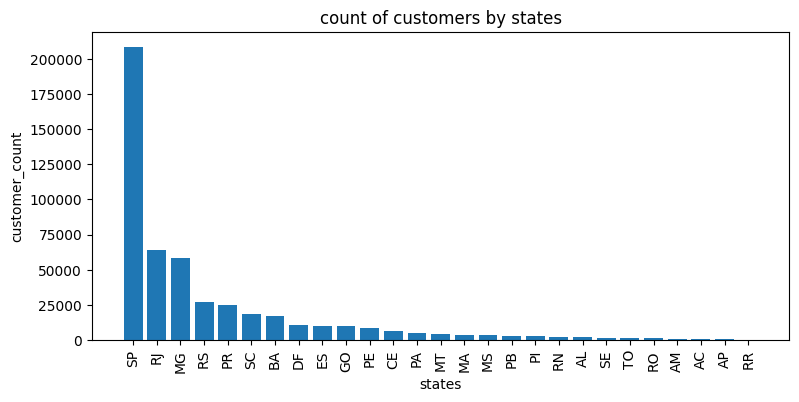

In [9]:
query = """ select customer_state, count(customer_id)
from customers group by customer_state
"""


cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["state", "customer_count"])
df = df.sort_values(by = "customer_count", ascending = False)

plt.figure(figsize = (9,4))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation=90)
plt.xlabel("states")
plt.ylabel("customer_count")
plt.title("count of customers by states")
plt.show()

# 6. Monthly Order Trend (2018)


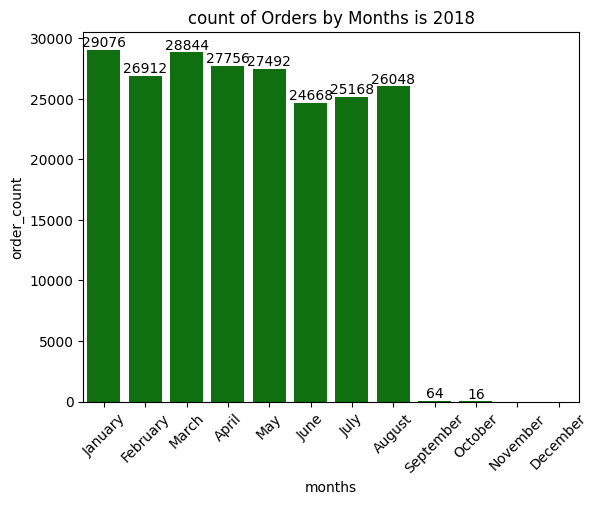

In [10]:
# SQL query to get month-wise order count for 2018
query = """
SELECT MONTHNAME(order_purchase_timestamp) AS months,
       COUNT(order_id) AS order_count
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2018
GROUP BY months
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["months", "order_count"])

o = ["January", "February", "March", "April", "May", "June",
     "July", "August", "September", "October", "November", "December"]

ax=sns.barplot(x="months", y="order_count", data=df, order=o,
             color="green")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("count of Orders by Months is 2018")
plt.show()


# 7. Avg Products Ordered by City

In [11]:
query = """ with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id)
as oc from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["customer city", "average product/order"])
df.head(10)

,customer city,average product/order
0,padre carvalho,112.00
1,celso ramos,104.00
2,datas,96.00
3,candido godoi,96.00
4,matias olimpio,80.00
5,cidelandia,64.00
6,curralinho,64.00
7,picarra,64.00
8,morro de sao paulo,64.00
9,teixeira soares,64.00


#  8. Product Categories - Revenue % Share

In [12]:
query = """
SELECT 
    UPPER(products.product_category) AS category,
    ROUND((SUM(payments.payment_value) / 
          (SELECT SUM(payment_value) FROM payments)) * 100, 2) AS sales_percentage
FROM products 
JOIN order_items ON products.product_id = order_items.product_id
JOIN payments ON payments.order_id = order_items.order_id
GROUP BY category 
ORDER BY sales_percentage DESC
"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["Category", "Percentage Distribution"])
df.head()

,Category,Percentage Distribution
0,BED TABLE BATH,171.16
1,HEALTH BEAUTY,165.65
2,COMPUTER ACCESSORIES,158.45
3,FURNITURE DECORATION,142.94
4,WATCHES PRESENT,142.84


# 9. Product Count and Average Price per Category

In [13]:
query = """ select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id= order_items.product_id
group by products.product_category;
"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["Category", "order_count", "price"])
import numpy as np
arr1 = df["order_count"]
arr2 = df["price"]
a=np.corrcoef([arr1,arr2])
print("the correlation is",
     a[0][-1])

the correlation is -0.10631514167157562


# 10. Top Revenue Generating Sellers

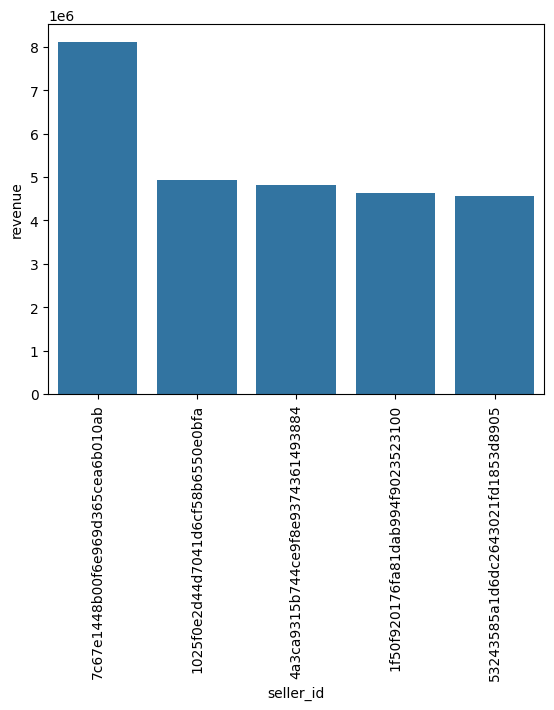

In [14]:
query = """ select *, dense_rank() over(order by revenue desc) as rn 
from
(select order_items.seller_id, sum(payments.payment_value)
revenue
from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["seller_id","revenue", "rank"])
df=df.head()
sns.barplot(x="seller_id", y="revenue", data=df)
plt.xticks(rotation = 90)
plt.show()

# 11. Moving Average of Payments

In [15]:
query = """ select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
...,...,...,...,...
1662171,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
1662172,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
1662173,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
1662174,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


# Cumulative Sales (Monthly)

In [16]:
query = """
SELECT 
    years, 
    months, 
    payment, 
    SUM(payment) OVER(ORDER BY years, months) AS cumulative_sales 
FROM (
    SELECT 
        YEAR(orders.order_purchase_timestamp) AS years,
        MONTH(orders.order_purchase_timestamp) AS months,
        ROUND(SUM(payments.payment_value), 2) AS payment 
    FROM orders 
    JOIN payments ON orders.order_id = payments.order_id
    GROUP BY years, months 
    ORDER BY years, months
) AS a
"""


cur.execute(query)
data = cur.fetchall()
df= pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,4035.84,4.035840e+03
1,2016,10,945447.68,9.494835e+05
2,2016,12,313.92,9.497974e+05
3,2017,1,2215808.64,3.165606e+06
4,2017,2,4670528.15,7.836134e+06
5,2017,3,7197817.59,1.503395e+07
6,2017,4,6684608.47,2.171856e+07
7,2017,5,9486701.12,3.120526e+07
8,2017,6,8180422.09,3.938568e+07
9,2017,7,9478126.71,4.886381e+07


# 13. YoY Sales Growth

In [17]:
query = """ with a as (SELECT YEAR(orders.order_purchase_timestamp) AS years,
        ROUND(SUM(payments.payment_value), 2) AS payment 
    FROM orders 
    JOIN payments ON orders.order_id = payments.order_id
    GROUP BY years
    ORDER BY years)

  select years, ((payment - lag(payment, 1) over(order by years))/
  lag(payment, 1) over(order by years)) *  100 from a"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["years", "yoy  % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703758
2,2018,20.000924


# 14. Repeat Customer Rate (Within 6 Months)

In [18]:
query = """ with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id 
"""

cur.execute(query)
data = cur.fetchall()
data

[(None,)]

# 15. Top 3 Customers by Yearly Revenue

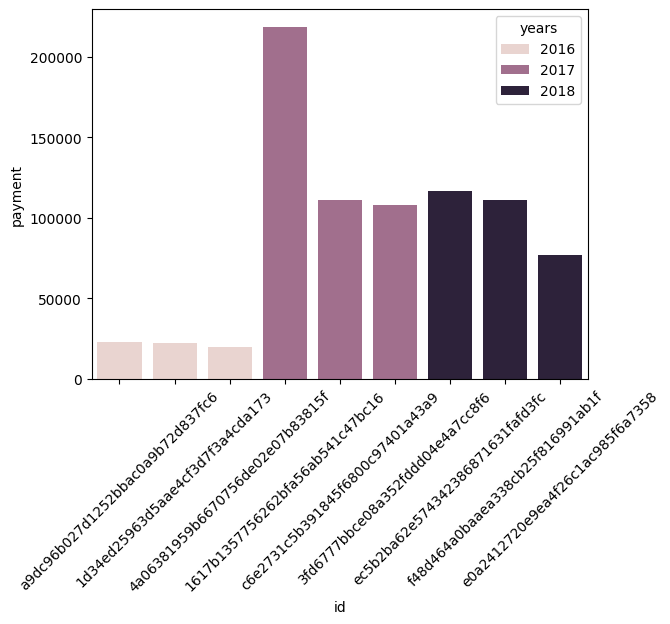

In [19]:
query = """ select years, customer_id, payment, d_rank
from 
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 

"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data, columns=["years", "id", "payment", "rank"])
sns.barplot(x= "id", y= "payment", data= df, hue = "years")
plt.xticks(rotation=45)
plt.show()

# Final Conclusion
This project successfully demonstrates a powerful combination of SQL and Python for real-world e-commerce data analysis. By using MySQL for structured querying and Python (Pandas, Seaborn, Matplotlib) for data manipulation and visualization, the project uncovers key business insights such as:

Most profitable product categories

Monthly and yearly sales trends

Regional customer distribution and state-wise engagement

Repeat purchase rates within 6 months

Top revenue-generating sellers and customers

This blend of SQL + Python enabled dynamic querying, automation of data import, and visual storytelling, making it valuable for business analysts, marketing strategists, and e-commerce platforms seeking data-driven decisions.